# Cornerstone Si_220nm_passive — Component Demo

Load Cornerstone foundry components from the vendored GDS+YAML library and visualize them in PhotonForge.

## Loading the Cornerstone PDK

In [1]:
# Make `cornerstone_forge` importable when running in-place. Skip if installed.
import sys, pathlib
_repo = pathlib.Path().resolve().parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import tidy3d as td
import matplotlib.pyplot as plt
import photonforge as pf
from IPython.display import SVG

import cornerstone_forge as cf

td.config.logging_level = "ERROR"

tech = cf.si220_passive()
pf.config.default_technology = tech


22:15:48 EDT WARNING: Using canonical configuration directory at                
             '/Users/prash_flexcompute/.config/tidy3d'. Found legacy directory  
             at '~/.tidy3d', which will be ignored. Remove it manually or run   
             'tidy3d config migrate --delete-legacy' to clean up.               

## Listing available components

`cornerstone-forge` v0.1.0 ships 29 components for `Si_220nm_passive`.

In [2]:
names = cf.list_components('Si_220nm_passive')
print(f"Total: {len(names)}")
for n in names[:10]:
    print(f"  {n}")
print(f"  ... and {len(names) - 10} more")


Total: 29
  Cell0_SOI220_Full_1550nm_Packaging_Template
  Heater
  SOI220nm_1310nm_TE_RIB_2x1_MMI
  SOI220nm_1310nm_TE_RIB_2x2_MMI
  SOI220nm_1310nm_TE_RIB_90_Degree_Bend
  SOI220nm_1310nm_TE_RIB_Grating_Coupler
  SOI220nm_1310nm_TE_RIB_Waveguide
  SOI220nm_1310nm_TE_RIB_Waveguide_Crossing
  SOI220nm_1310nm_TE_STRIP_2x1_MMI
  SOI220nm_1310nm_TE_STRIP_2x2_MMI
  ... and 19 more


## Loading a single component

`cf.component(name)` reads the foundry GDS via `pf.load_layout`, attaches ports from the YAML metadata, and returns a `pf.Component`.

In [3]:
mmi = cf.component('SOI220nm_1550nm_TE_STRIP_2x1_MMI')
mmi


In [4]:
print(f"name   : {mmi.name}")
print(f"bounds : {mmi.bounds()}")
print(f"ports  :")
for pname, p in mmi.ports.items():
    print(f"   {pname}: center={tuple(p.center)}  orientation={p.input_direction:.0f}  spec={p.spec.description}")


name   : SOI220nm_1550nm_TE_STRIP_2x1_MMI
bounds : (array([ 0., -3.]), array([91.8,  3. ]))
ports  :
   o1: center=(np.float64(0.0), np.float64(0.0))  orientation=0  spec=Strip TE/TM 1550 nm, w=450 nm
   o2: center=(np.float64(91.80000000000001), np.float64(1.57))  orientation=180  spec=Strip TE/TM 1550 nm, w=450 nm
   o3: center=(np.float64(91.80000000000001), np.float64(-1.57))  orientation=180  spec=Strip TE/TM 1550 nm, w=450 nm


## Cross-section visualization

Slice the loaded component with `pf.tidy3d_plot` and look at the structures along the propagation direction.

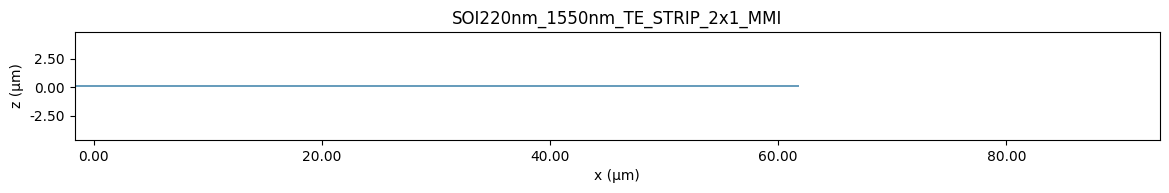

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
pf.tidy3d_plot(mmi, plot_type="structures", y=0.0, ax=ax)
ax.set_title(mmi.name)
plt.show()


Or render the full 3D geometry.

In [6]:
pf.tidy3d_plot(mmi, plot_type="3d")

## A heater (electrical component)

Cornerstone heaters use the TiN filament + Al pad metal stack. The two electrical_dc ports map to the `dc` port spec in the technology.

In [7]:
heater = cf.component('Heater')
display(SVG(heater._repr_svg_()))
print('ports:', list(heater.ports.keys()))


ports: []


## A grating coupler

Grating couplers expose only their in-plane optical port; the fiber-side metadata (vertical port, coupling angle, fiber type) is stored in `component.properties`.

In [8]:
gc = cf.component('SOI220nm_1550nm_TE_STRIP_Grating_Coupler')
display(SVG(gc._repr_svg_()))
print('in-plane ports:', list(gc.ports.keys()))
print('fiber-side metadata:', dict(gc.properties))


in-plane ports: ['o1', 'vertical_te']
fiber-side metadata: {}


## Adding a Tidy3D model

Components from the vendored library carry an empty `pf.Tidy3DModel()` by default. v0.1.0 is layout-only — to compute S-parameters you can configure the model and call `component.s_matrix(...)` as you would with any PhotonForge component (compact / pre-baked S-parameter models for these cells are planned for v0.2.0).

In [9]:
mmi.add_model(pf.Tidy3DModel(), 'Tidy3D')  # no-op: already attached, but illustrates the API
mmi.models


{'Tidy3D': Tidy3DModel(run_time=None, medium=None, symmetry=(0, 0, 0), boundary_spec=None, monitors=(), structures=(), grid_spec=None, shutoff=None, subpixel=None, courant=None, port_symmetries=(), bounds=((None, None, None), (None, None, None)), source_gap=None, simulation_updates={}, verbose=True)}

## Browsing the whole library

The repo ships an HTML dashboard (`output/Si_220nm_passive/dashboard.html`) that includes a layer table, the stack-up cross-section above, a port-spec summary, the verification scoreboard, and an embedded PhotonForge `LiveViewer` showing every component side-by-side. To launch it:

```bash
python agent_loop/dashboard.py Si_220nm_passive
# then open output/Si_220nm_passive/dashboard.html
```